In [ ]:
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
periods = pd.read_pickle("../data/prepared/periods_15m.pickle")
periods = list(filter(lambda p: p["history"][-1]["image_name"].startswith("2014"), periods))

timestamps = [(datetime.strptime(p['history'][-1]['image_name'].split('.')[0], "%Y%m%d_%H%M%S") + timedelta(minutes=15)).strftime("%Y-%m-%d %H:%M:%S") for p in periods]
actual = np.array([float(p['target_irradiance']) for p in periods])
targets = np.load("targets_resnet50.npy")

assert len(actual) == len(timestamps), "Length of actual data and timestamps do not match."
assert len(actual) == len(targets), "Length of actual data and targets do not match."
assert np.allclose(actual, targets), "Actual data and targets do not match."

model_predictions = np.load("predictions_resnet50.npy")
model_predictions = np.clip(model_predictions, 0, None)

assert len(actual) == len(model_predictions), "Length of actual data and model output do not match."

smart_persistence_predictions = np.load("smart_persistence_15min.npy")

assert len(actual) == len(smart_persistence_predictions), "Length of actual data and clear sky model do not match."

In [3]:
# Use raw values normalized to the standard test conditions (STC = 1000 W/m²)
actual_pu = actual / 1000
model_pu = model_predictions / 1000
smart_persistence_pu = smart_persistence_predictions / 1000

print("Raw stats (min/median/max/std)")

for name, arr in [("actual", actual_pu), ("proposed", model_pu), ("baseline", smart_persistence_pu)]:
    print(f"{name:9s}: {arr.min():.3f} / {np.median(arr):.3f} / {arr.max():.3f} / {arr.std():.3f}")

# Baseline variability check to ensure no flat artifacts
unique_baseline = len(np.unique(smart_persistence_pu))
print(f"Baseline unique values: {unique_baseline}")

Raw stats (min/median/max/std)
actual   : 0.000 / 0.401 / 1.366 / 0.292
proposed : 0.000 / 0.404 / 1.088 / 0.287
baseline : 0.000 / 0.400 / 1.350 / 0.292
Baseline unique values: 224335


### BESS Wear & Tear

In [4]:
def calc_battery_throughput(act, fcst, eff_rt=0.92, capacity_kw=1000, dt_hours=0.25, debias=True):
    """Total kWh cycled to chase forecast; debias removes net drift."""
    power_kw = (fcst - act) * capacity_kw
    if debias:
        power_kw = power_kw - power_kw.mean()
    throughput_kwh = np.sum(np.abs(power_kw) * dt_hours / eff_rt)
    return throughput_kwh


bat_prop = calc_battery_throughput(actual_pu, model_pu)
bat_sota = calc_battery_throughput(actual_pu, smart_persistence_pu)

print("--- BESS wear (throughput, debiased, eff=92%) ---")
print(f"Proposed Model Battery Cycling: {bat_prop:,.1f} kWh")
print(f"Smart Persistence Model Battery Cycling: {bat_sota:,.1f} kWh")
print(f"Reduction in Battery Wear:      {(1 - bat_prop/max(bat_sota,1e-9))*100:5.1f}%")

--- BESS wear (throughput, debiased, eff=92%) ---
Proposed Model Battery Cycling: 1,783,348.9 kWh
Smart Persistence Model Battery Cycling: 2,250,356.4 kWh
Reduction in Battery Wear:       20.8%


### BESS sizing for forecast-following dispatch

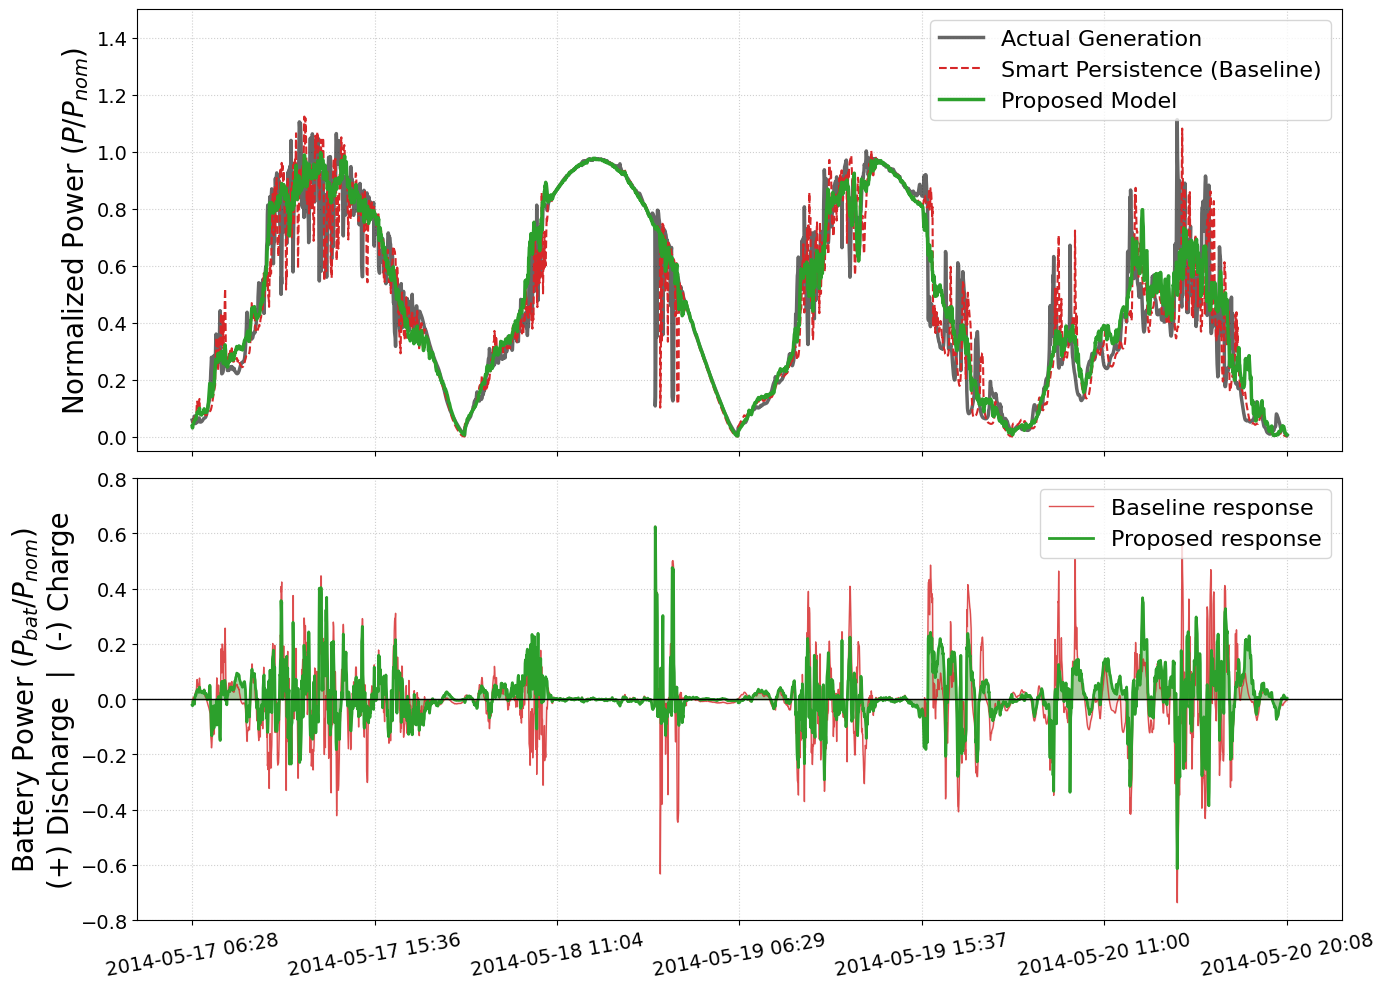

In [ ]:
def plot_bess_results(act, fcst_prop, fcst_ref, start_idx, length, dt_hours=0.25):
    """
    Generates a publication-quality composite figure showing Generation Profiles and Battery Response.
    Includes embedded metrics and timestamp-based x-axis.
    
    Args:
        act (array): Actual generation (per unit)
        fcst_prop (array): Proposed model forecast
        fcst_ref (array): Reference/Baseline forecast
        start_idx (int): Start index for the zoom window
        length (int): Number of steps to show (96 = 24 hours)
        dt_hours (float): Time step duration (0.25 = 15 mins)
    """
    
    # 1. Slice Data
    sub_act = act[start_idx : start_idx+length]
    sub_prop = fcst_prop[start_idx : start_idx+length]
    sub_ref = fcst_ref[start_idx : start_idx+length]
    
    # Extract timestamps for the window
    window_timestamps = timestamps[start_idx : start_idx+length]
    time_indices = np.arange(length)
    
    # 2. Calculate Battery Actions (Forecast - Actual)
    bess_prop = sub_prop - sub_act
    bess_ref = sub_ref - sub_act
    
    # Calculate Throughput for this specific window
    th_prop = np.sum(np.abs(bess_prop)) * dt_hours
    th_ref = np.sum(np.abs(bess_ref)) * dt_hours
    improvement = ((th_ref - th_prop) / th_ref) * 100
    
    # 3. Create Figure
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [1, 1]})
    
    # --- Panel 1: generation profiles ---
    ax1.plot(time_indices, sub_act, color='black', linewidth=2.5, alpha=0.6, label='Actual Generation')
    ax1.plot(time_indices, sub_ref, color='#d62728', linestyle='--', linewidth=1.5, label='Smart Persistence (Baseline)')
    ax1.plot(time_indices, sub_prop, color='#2ca02c', linewidth=2.5, label='Proposed Model')
    
    ax1.set_ylim(-0.05, 1.50)
    ax1.yaxis.set_tick_params(labelsize=14)
    ax1.set_ylabel(r'Normalized Power ($P/P_{nom}$)', fontsize=20)
    # ax1.text(0.02, 0.95, 'A', transform=ax1.transAxes, fontsize=20, fontweight='bold', va='top')
    ax1.legend(loc='upper right', frameon=True, fontsize=16)
    ax1.grid(True, linestyle=':', alpha=0.6)
    
    # --- Panel 2: battery response (wear & tear) ---
    ax2.plot(time_indices, bess_ref, color='#d62728', linewidth=1, alpha=0.8, label='Baseline response')
    ax2.fill_between(time_indices, bess_ref, color='#d62728', alpha=0.1)
    
    ax2.plot(time_indices, bess_prop, color='#2ca02c', linewidth=2, label='Proposed response')
    ax2.fill_between(time_indices, bess_prop, color='#2ca02c', alpha=0.4)
    
    ax2.axhline(0, color='black', linewidth=1)
    ax2.set_ylim(-0.8, 0.8)

    ax2.set_ylabel(r'Battery Power ($P_{bat}/P_{nom}$)' + '\n(+) Discharge  |  (-) Charge', fontsize=20)
    # ax2.text(0.02, 0.95, 'B', transform=ax2.transAxes, fontsize=20, fontweight='bold', va='top')
    # ax2.set_title('B. Battery Power and Cycling Stress', fontsize=18, fontweight='bold', loc='left')
    ax2.legend(loc='upper right', frameon=True, fontsize=16)
    ax2.grid(True, linestyle=':', alpha=0.6)
    
    # Set x-axis ticks to show timestamps at reasonable intervals
    tick_step = max(1, length // 6)  # Show ~6 timestamps
    ax2.set_xticks(time_indices[::tick_step])
    ax2.set_xticklabels([window_timestamps[i][:-3] for i in range(0, length, tick_step)], rotation=10, ha='center', fontsize=14)
    ax2.yaxis.set_tick_params(labelsize=14)
    
    plt.tight_layout()
    plt.savefig(f"Figure_11_BESS_simulation.pdf", format='pdf')

plot_bess_results(actual_pu, model_pu, smart_persistence_pu, start_idx=81265, length=3290)


### Ramp-rate control and curtailment

In [8]:
ramp_limit = 0.15  # per-unit/15-min
dt_hours = 0.25  # 15 minutes
capacity_kw = 1000  # 1 MW plant


def apply_ramp_limit(series, limit):
    """Ramp-limit a trajectory; returns smoothed series and curtailed energy vs. requested."""
    smoothed = [series[0]]
    curtailed_kwh = 0.0

    for val in series[1:]:
        upper = smoothed[-1] + limit
        lower = smoothed[-1] - limit
        clipped = min(max(val, lower), upper)
        smoothed.append(clipped)
        curtailed_kwh += max(0.0, val - clipped) * capacity_kw * dt_hours

    return np.array(smoothed), curtailed_kwh


# Evaluate ramp events on per-unit signals
act_ramp = np.abs(np.diff(actual_pu)) > ramp_limit
prop_ramp = np.abs(np.diff(model_pu)) > ramp_limit
sota_ramp = np.abs(np.diff(smart_persistence_pu)) > ramp_limit

smoothed_prop, curtailed_prop = apply_ramp_limit(model_pu, ramp_limit)
smoothed_sota, curtailed_sota = apply_ramp_limit(smart_persistence_pu, ramp_limit)

print("--- Ramp-rate control & curtailment (per-unit trajectories) ---")
print(f"Ramp events in data: {np.sum(act_ramp)}")
print(f"Events predicted (proposed): {np.sum(prop_ramp)} | recall {np.sum(act_ramp & prop_ramp)/max(np.sum(act_ramp),1)*100:5.1f}% | precision {np.sum(act_ramp & prop_ramp)/max(np.sum(prop_ramp),1)*100:5.1f}%")
print(f"Events predicted (smart persistence): {np.sum(sota_ramp)} | recall {np.sum(act_ramp & sota_ramp)/max(np.sum(act_ramp),1)*100:5.1f}% | precision {np.sum(act_ramp & sota_ramp)/max(np.sum(sota_ramp),1)*100:5.1f}%")
print("")
print(f"Curtailment vs. requested forecast (proposed): {curtailed_prop:,.1f} kWh")
print(f"Curtailment vs. requested forecast (smart persistence): {curtailed_sota:,.1f} kWh")
print(f"Curtailment reduction vs. smart persistence: {(1 - curtailed_prop/max(curtailed_sota,1e-9))*100:5.1f}%")

--- Ramp-rate control & curtailment (per-unit trajectories) ---
Ramp events in data: 3027
Events predicted (proposed): 153 | recall   1.5% | precision  29.4%
Events predicted (smart persistence): 3052 | recall  19.3% | precision  19.1%

Curtailment vs. requested forecast (proposed): 672.0 kWh
Curtailment vs. requested forecast (smart persistence): 52,327.6 kWh
Curtailment reduction vs. smart persistence:  98.7%
